### Bayesian Inference

#### Prior and Posterior

For $\theta \in \Theta$ (parameter space), and $\pi(\cdot)$ the prior of $\theta$, we observe $X_1, \dots, X_n$ conditional on parameter $\theta$ with $L_n(\theta| X_1, \dots, X_n)$.

$\phi$ is a placeholder (the integral) that does not depend on parameter $\theta$, and we normally refer to it as a normalization constant.

$\phi(X_1, \dots, X_n)$ depends on the observations.

The posterior is given by:
- $\pi(\theta|X_1, \dots, X_n) = \pi(\theta) \cdot L_n(X_1, \dots, X_n| \theta) \cdot \phi(X_1, \dots, X_n)$
- $L_n(X_1,\dots,X_n) = L_{n-1}(X_1,\dots,X_n) L_1(X_n|\theta)$
- $\pi(\theta|X_1,\dots,X_n) = \pi(\theta|X_1,\dots,X_{n-1}) \cdot L_1(X_n|\theta) \cdot \phi(X_1,\dots,X_n)$

To derive the expression for the normalization constant $\phi(X_1, \dots, X_n)$, we start with the definition of the posterior:

$\pi(\theta|X_1, \dots, X_n) = \pi(\theta) \cdot L_n(X_1, \dots, X_n| \theta) \cdot \phi(X_1, \dots, X_n)$

We know that a probability distribution must integrate to 1 over its parameter space $\Theta$, $\int_{\Theta} \pi(\theta|X_1, \dots, X_n) d\theta = 1$. Substitute the expression for the posterior into the integral $\int_{\Theta} \left( \pi(\theta) \cdot L_n(X_1, \dots, X_n| \theta) \cdot \phi(X_1, \dots, X_n) \right) d\theta = 1$

Since $\phi(X_1, \dots, X_n)$ does not depend on $\theta$, we can pull it out of the integral $\phi(X_1, \dots, X_n) \int_{\Theta} \pi(\theta) \cdot L_n(X_1, \dots, X_n| \theta) d\theta = 1$

Finally, we can solve for $\phi(X_1, \dots, X_n)$:
- $\phi(X_1, \dots, X_n) = \frac{1}{\int_{\Theta} \pi(\theta) \cdot L_n(X_1, \dots, X_n| \theta) d\theta}$.

This integral in the denominator is also known as the marginal likelihood or evidence.


##### Prior Implications to Posterior
Given $\theta \in \{0,1\}$ with prior probabilities $\pi(0) = p$ and $\pi(1) = 1-p$, show the relationship between the prior and posterior:

- For $p < 0.5$: The prior favors $\theta=1$. This generally leads to a posterior where $\pi(\theta=0|X_1,\dots,X_n) < \pi(\theta=1|X_1,\dots,X_n)$, meaning that after observing data, $\theta=1$ is still more probable than $\theta=0$, unless the likelihood strongly contradicts this.

- For $p > 0.5$: The prior favors $\theta=0$. This generally leads to a posterior where $\pi(\theta=0|X_1,\dots,X_n) > \pi(\theta=1|X_1,\dots,X_n)$, meaning that after observing data, $\theta=0$ is still more probable than $\theta=1$, unless the likelihood strongly contradicts this.

- For $p = 0.5$: The prior is neutral (equal probability for $\theta=0$ and $\theta=1$). The posterior will then be solely determined by the likelihood function $L_n(X_1,\dots,X_n|\theta)$.

- $p = 0$: The prior is certain that $\theta=1$. Specifically, $\pi(0) = 0$ and $\pi(1) = 1$. In this scenario, the posterior will also be certain that $\theta=1$, i.e., $\pi(\theta=0|X_1,\dots,X_n) = 0$ and $\pi(\theta=1|X_1,\dots,X_n) = 1$, regardless of the observed data, as a prior of zero cannot be overcome by any finite likelihood.

- $p = 1$: The prior is certain that $\theta=0$. Specifically, $\pi(0) = 1$ and $\pi(1) = 0$. Similarly, the posterior will be certain that $\theta=0$, i.e., $\pi(\theta=0|X_1,\dots,X_n) = 1$ and $\pi(\theta=1|X_1,\dots,X_n) = 0$, regardless of the observed data.

##### Visualizing Prior's Effect on Posterior

How different prior probabilities for $\theta=0$ (denoted as $p$) influence the posterior probabilities. We'll assume a simple scenario with a binary $theta$ and a fixed likelihood.

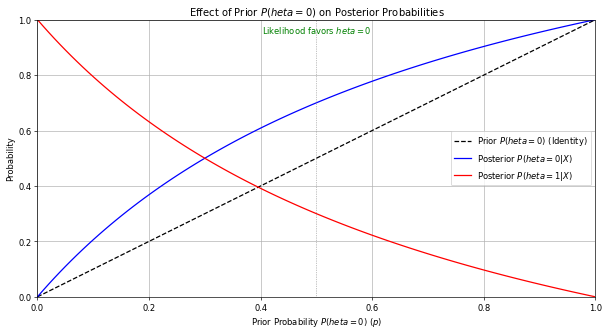

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Assume some observed data X. For simplicity, we'll define a fixed likelihood.
# Let's say our observed data X makes theta=0 slightly more likely than theta=1.
# Likelihood L(X|theta):
# P(X|theta=0) = 0.7
# P(X|theta=1) = 0.3

L_given_theta_0 = 0.7
L_given_theta_1 = 0.3

def calculate_posterior(p, L_0, L_1):
    """
    Calculates the posterior probabilities for theta=0 and theta=1.

    Args:
        p (float): Prior probability of theta=0 (P(theta=0)).
        L_0 (float): Likelihood P(X|theta=0).
        L_1 (float): Likelihood P(X|theta=1).

    Returns:
        tuple: (posterior_theta_0, posterior_theta_1)
    """
    # Prior for theta=1
    p_theta_1 = 1 - p

    # Unnormalized posterior numerator
    numerator_theta_0 = p * L_0
    numerator_theta_1 = p_theta_1 * L_1

    # Normalization constant (marginal likelihood)
    marginal_likelihood = numerator_theta_0 + numerator_theta_1

    # Posterior probabilities
    posterior_theta_0 = numerator_theta_0 / marginal_likelihood
    posterior_theta_1 = numerator_theta_1 / marginal_likelihood

    return posterior_theta_0, posterior_theta_1

# Generate a range of prior probabilities p
p_values = np.linspace(0, 1, 100)

# Calculate posteriors for each p_value
posterior_0_values = []
posterior_1_values = []

for p in p_values:
    post_0, post_1 = calculate_posterior(p, L_given_theta_0, L_given_theta_1)
    posterior_0_values.append(post_0)
    posterior_1_values.append(post_1)

If $p < 1/2$ the posterior distribution for $\theta =0$ is less than the posterior on $\theta =1$, is not a true statement.

In [4]:
# Choose a prior p < 0.5, for example, p = 0.2
p_example = 0.2

# Calculate posterior probabilities
posterior_0_ex, posterior_1_ex = calculate_posterior(p_example, L_given_theta_0, L_given_theta_1)

print(f"For prior P(theta=0) = {p_example}:\n"
f"  Posterior P(theta=0|X) = {posterior_0_ex:.4f} \n"
f"  Posterior P(theta=1|X) = {posterior_1_ex:.4f}")

# Demonstrate the condition: prior P(theta=0) < posterior P(theta=1|X)
print(f"\nIs prior P(theta=0) < posterior P(theta=1|X)? {p_example} < {posterior_1_ex:.4f} is {p_example < posterior_1_ex}")

For prior P(theta=0) = 0.2:
  Posterior P(theta=0|X) = 0.3684
  Posterior P(theta=1|X) = 0.6316

Is prior P(theta=0) < posterior P(theta=1|X)? 0.2 < 0.6316 is True


If $p > 1/2$ the posterior distribution for $\theta =0$ is grater than the posterior on $\theta =1$, is not a true statement.

In [6]:
# Choose a prior p < 0.5, for example, p = 0.4, where the condition might not hold
p_example_2 = 0.4

# Calculate posterior probabilities
posterior_0_ex_2, posterior_1_ex_2 = calculate_posterior(p_example_2, L_given_theta_0, L_given_theta_1)

print(f"\nAnother Example \n"
f"For prior P(theta=0) = {p_example_2}: \n"
f"  Posterior P(theta=0|X) = {posterior_0_ex_2:.4f} \n"
f"  Posterior P(theta=1|X) = {posterior_1_ex_2:.4f}")

# Demonstrate the condition: prior P(theta=0) < posterior P(theta=1|X)
print(f"\nIs prior P(theta=0) < posterior P(theta=1|X)? {p_example_2} < {posterior_1_ex_2:.4f} is {p_example_2 < posterior_1_ex_2}")


Another Example 
For prior P(theta=0) = 0.4: 
  Posterior P(theta=0|X) = 0.6087 
  Posterior P(theta=1|X) = 0.3913

Is prior P(theta=0) < posterior P(theta=1|X)? 0.4 < 0.3913 is False


The relationship between the prior probability $P(\theta=0)$ and the resulting posterior probabilities $P(\theta=0|X)$ and $P(\theta=1|X)$.

1. **Likelihood's Influence**: We set the likelihood to favor $\theta=0$ ($L(X|\theta=0) = 0.7$ and $L(X|\theta=1) = 0.3$). You can see that the blue line (posterior for $\theta=0$) is generally higher than the black dashed line (prior for $\theta=0$) for most prior values, especially when the prior for $\theta=0$ is low. This demonstrates how the observed data, which favors $\theta=0$, pulls the posterior probability towards $\theta=0$.
2. **Balancing Act**: The posterior probability for $\theta=0$ increases as the prior for $\theta=0$ increases, but it's always tempered by the likelihood. The data prevents the posterior from simply mirroring the prior entirely.
3. **Neutral Prior** ($P(\theta=0)=0.5$): At the gray vertical line where the prior is 0.5, the posterior probabilities are solely determined by the relative strengths of the likelihoods. Since $L(X|\theta=0) > L(X|\theta=1)$, the posterior $P(\theta=0|X)$ is greater than $P(\theta=1|X)$ at this point.
4. **Strong Priors**: When the prior $P(\theta=0)$ is very close to 0 or 1, the posterior tends to stay close to these extreme values. For example, if you are very certain initially that $P(\theta=0)=0$ (far left), even strong evidence for $\theta=0$ from the likelihood won't shift your belief drastically, illustrating that a prior of zero cannot be overcome. Conversely, if you are very certain that $P(\theta=0)=1$ (far right), the posterior remains high for $\theta=0$.

In essence, the plot clearly visualizes how Bayesian inference updates beliefs: the posterior is a weighted average of the prior and the evidence provided by the likelihood, with the strength of the prior determining how much the new data can shift your belief.

#### Beta Distribution and its Mode

The Beta distribution is a continuous probability distribution defined on the interval $[0, 1]$, with its PDF is given by:

$f(x; \alpha, \beta) = C(\alpha, \beta) x^{\alpha - 1} (1 - x)^{\beta - 1}$

where $\alpha > 0$ and $\beta > 0$ are shape parameters, and $C(\alpha, \beta)$ is a normalization constant. The shape of the Beta distribution, and thus the location of its mode(s), varies significantly with different values of $\alpha$ and $\beta$.

We will now visualize the PDF for different parameter sets and identify their modes. If a unique mode does not exist (e.g., for U-shaped or uniform distributions), it will be represented by -1.

In [59]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

# Helper function to get the mode(s) of the Beta distribution
def get_beta_mode(alpha, beta_val):
    if alpha <= 0 or beta_val <= 0:
        return "Parameters must be > 0"
    elif alpha == 1 and beta_val == 1:
        return [-1]  # No unique mode (Uniform), return -1 as per requirement
    elif alpha < 1 and beta_val < 1:
        return [-1]  # U-shaped, two modes, so no unique mode. Return -1.
    elif alpha > 1 and beta_val > 1:
        mode = (alpha - 1) / (alpha + beta_val - 2)
        return [mode]
    elif alpha <= 1 and beta_val >= 1:
        return [0]
    elif alpha >= 1 and beta_val <= 1:
        return [1]
    else:
        return [] # Should not be reached with alpha, beta > 0

In [60]:
# Function to plot the Beta distribution and its mode(s)
def plot_beta_distribution(alpha, beta_val, ax):
    x = np.linspace(0.001, 0.999, 500) # Avoid exact 0 and 1 for log-likelihood issues in some cases
    y = beta.pdf(x, alpha, beta_val)

    ax.plot(x, y, label=f'α={alpha}, β={beta_val}')
    ax.set_title(f'Beta Distribution PDF (α={alpha}, β={beta_val})')
    ax.set_xlabel('x')
    ax.set_ylabel('PDF')
    ax.set_ylim(bottom=0) # Ensure y-axis starts at 0

    modes = get_beta_mode(alpha, beta_val)
    print(f"DEBUG: alpha={alpha}, beta_val={beta_val}, modes={modes}")

    if modes == [-1]: # Check for the new -1 representation of no unique mode
        ax.text(0.5, ax.get_ylim()[1] * 0.9, "Mode: No unique mode (e.g., U-shaped or Uniform)",
                horizontalalignment='center', verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="k", lw=1, alpha=0.6))
    elif isinstance(modes, list) and modes: # Ensure modes is a non-empty list
        for mode_val in modes:
            if mode_val == 0:
                ax.axvline(x=0.001, color='r', linestyle='--', alpha=0.7)
                ax.text(0.05, ax.get_ylim()[1] * 0.9, 'Mode at x=0', color='r',
                        horizontalalignment='left', verticalalignment='top',
                        bbox=dict(boxstyle="round,pad=0.3", fc="red", ec="k", lw=1, alpha=0.6))
            elif mode_val == 1:
                ax.axvline(x=0.999, color='r', linestyle='--', alpha=0.7)
                ax.text(0.95, ax.get_ylim()[1] * 0.9, 'Mode at x=1', color='r',
                        horizontalalignment='right', verticalalignment='top',
                        bbox=dict(boxstyle="round,pad=0.3", fc="red", ec="k", lw=1, alpha=0.6))
            else: # This handles single internal mode cases
                ax.axvline(x=mode_val, color='r', linestyle='--', alpha=0.7)
                ax.plot(mode_val, beta.pdf(mode_val, alpha, beta_val), 'ro', markersize=8)
                ax.text(mode_val, beta.pdf(mode_val, alpha, beta_val) + ax.get_ylim()[1] * 0.05,
                        f'Mode: {mode_val:.3f}', color='r', horizontalalignment='center',
                        bbox=dict(boxstyle="round,pad=0.3", fc="red", ec="k", lw=1, alpha=0.6))
    # Handle the "Parameters must be > 0" case
    elif isinstance(modes, str):
        ax.text(0.5, ax.get_ylim()[1] * 0.9, f"Mode: {modes}",
                horizontalalignment='center', verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", fc="red", ec="k", lw=1, alpha=0.6))

##### Case 1: $\alpha < 1$ and $\beta < 1$

In this case, the Beta distribution is U-shaped, with modes at the boundaries $x=0$ and $x=1$.

DEBUG: alpha=0.5, beta_val=0.5, modes=[0, 1]
DEBUG: alpha=0.2, beta_val=0.8, modes=[0, 1]


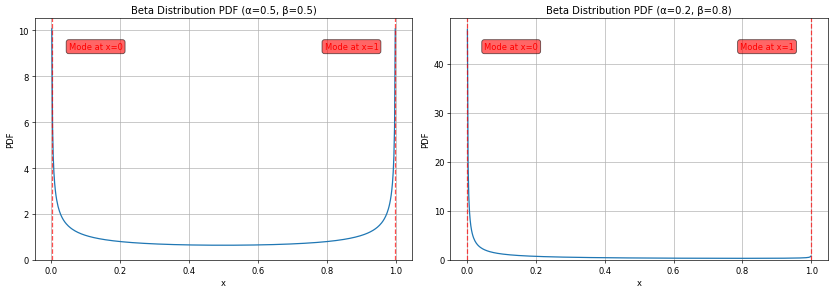

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=60)

# Example 1: Symmetric U-shape
plot_beta_distribution(0.5, 0.5, axes[0])
# Example 2: Asymmetric U-shape
plot_beta_distribution(0.2, 0.8, axes[1])

plt.show()

##### Case 2: $\alpha \le 1$ and $\beta \ge 1$

Excluding the uniform case ($\alpha=1, \beta=1$), the mode of the distribution is at $x=0$. The PDF is generally decreasing.

DEBUG: alpha=0.5, beta_val=2, modes=[0]
DEBUG: alpha=1, beta_val=3, modes=[0]


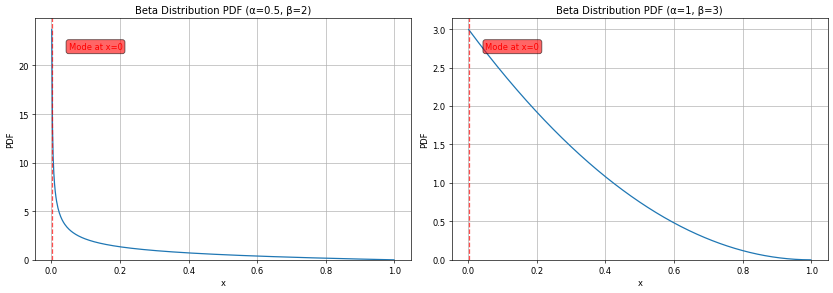

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=60)

# Example 1: alpha < 1, beta > 1
plot_beta_distribution(0.5, 2, axes[0])
# Example 2: alpha = 1, beta > 1 (linear decreasing)
plot_beta_distribution(1, 3, axes[1])

plt.show()

##### Case 3: $\alpha \ge 1$ and $\beta \le 1$

Excluding the uniform case ($\alpha=1, \beta=1$), the mode of the distribution is at $x=1$. The PDF is generally increasing.

DEBUG: alpha=2, beta_val=0.5, modes=[1]
DEBUG: alpha=3, beta_val=1, modes=[1]


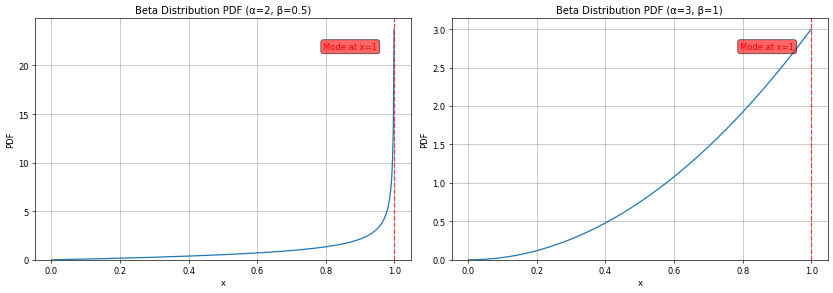

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=60)

# Example 1: alpha > 1, beta < 1
plot_beta_distribution(2, 0.5, axes[0])
# Example 2: alpha > 1, beta = 1 (linear increasing)
plot_beta_distribution(3, 1, axes[1])

plt.show()

##### Case 4: $\alpha$ = $\beta$ = $1$

When $\alpha = 1$ and $\beta = 1$, the Beta distribution simplifies to a uniform distribution over $[0, 1]$. In this case, every point in the interval is a mode.

DEBUG: alpha=1, beta_val=1, modes=['Uniform (all points are modes)']


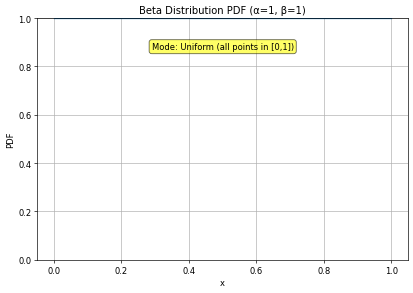

In [54]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=60)
plot_beta_distribution(1, 1, ax)
plt.show()

##### Case 5: $\alpha > 1$ and $\beta > 1$

In this scenario, the Beta distribution is unimodal (bell-shaped), with the mode located at $x = (\alpha - 1) / (\alpha + \beta - 2)$.

DEBUG: alpha=2, beta_val=2, modes=[0.5]
DEBUG: alpha=5, beta_val=2, modes=[0.8]


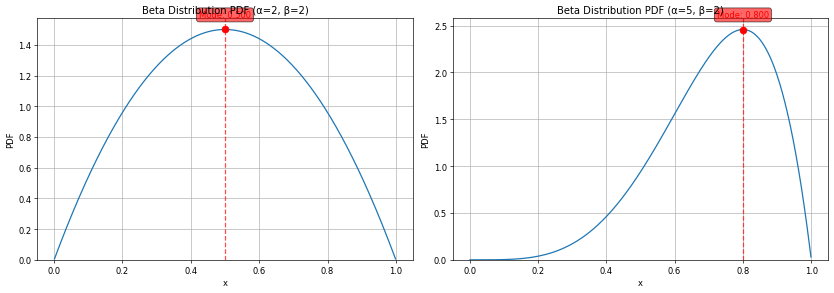

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=60)

# Example 1: Symmetric bell-shape
plot_beta_distribution(2, 2, axes[0])
# Example 2: Asymmetric bell-shape
plot_beta_distribution(5, 2, axes[1])

plt.show()

##### New Example: $\alpha > 1$ and $\beta > 1$

Here's another example for the bell-shaped Beta distribution, where both $\alpha$ and $\beta$ are greater than 1.

DEBUG: alpha=3, beta_val=4, modes=[0.4]


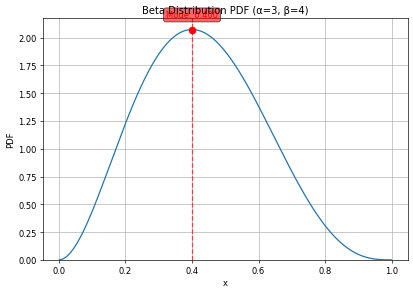

In [56]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=60)

# Example for alpha > 1 and beta > 1
plot_beta_distribution(3, 4, ax)

plt.show()

#### Consolidated: All Beta Distribution Cases on a Single Plot

This displays various Beta distribution PDFs with different parameter sets on a single figure. It serves as a comprehensive overview of how $\alpha$ and $\beta$ influence the shape and mode(s) of the distribution, encompassing all the cases discussed.

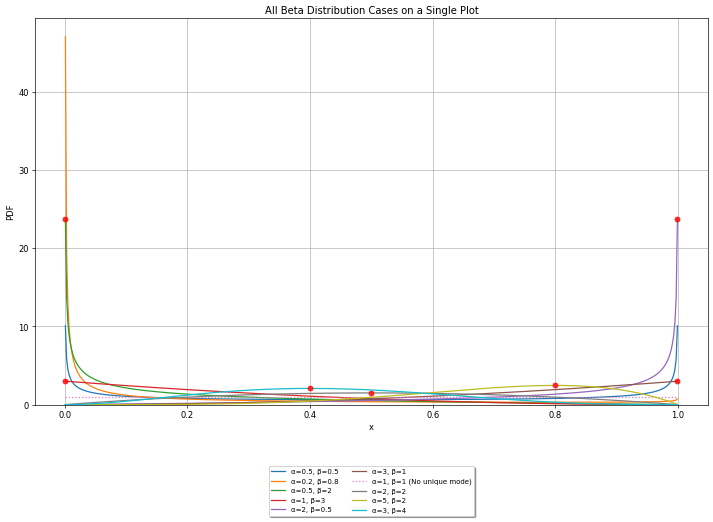

In [61]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=60)

x = np.linspace(0.001, 0.999, 500)

# Define different (alpha, beta) pairs covering all cases
beta_params = [
    (0.5, 0.5),  # Case 1: U-shaped
    (0.2, 0.8),  # Case 1: Asymmetric U-shaped
    (0.5, 2),    # Case 2: Mode at 0
    (1, 3),      # Case 2: Mode at 0 (linear decreasing)
    (2, 0.5),    # Case 3: Mode at 1
    (3, 1),      # Case 3: Mode at 1 (linear increasing)
    (1, 1),      # Case 4: Uniform
    (2, 2),      # Case 5: Symmetric bell-shaped
    (5, 2),      # Case 5: Asymmetric bell-shaped
    (3, 4)       # Case 5: Another asymmetric bell-shaped
]

for alpha, beta_val in beta_params:
    if alpha == 1 and beta_val == 1:
        # For uniform distribution, handle plotting slightly differently for clarity
        ax.plot(x, np.full_like(x, 1), label=f'α={alpha}, β={beta_val} (No unique mode)', linestyle=':')
    else:
        y = beta.pdf(x, alpha, beta_val)
        ax.plot(x, y, label=f'α={alpha}, β={beta_val}')

        # Add mode markers
        modes = get_beta_mode(alpha, beta_val)
        # Only plot markers if there's a unique, non-negative mode
        if modes and modes != [-1] and isinstance(modes, list):
            for mode_val in modes:
                if mode_val == 0:
                    ax.plot(0.001, beta.pdf(0.001, alpha, beta_val), 'o', color='red', markersize=6, alpha=0.8)
                elif mode_val == 1:
                    ax.plot(0.999, beta.pdf(0.999, alpha, beta_val), 'o', color='red', markersize=6, alpha=0.8)
                else:
                    ax.plot(mode_val, beta.pdf(mode_val, alpha, beta_val), 'o', color='red', markersize=6, alpha=0.8)

ax.set_title('All Beta Distribution Cases on a Single Plot')
ax.set_xlabel('x') ; ax.set_ylabel('PDF')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=2, fontsize='small')
ax.grid(True) ; ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
plt.tight_layout(rect=[0, 0.1, 1, 1]) ; plt.show() # Adjust layout for legend

#### Effect of Varying $\alpha$ (Beta Constant)

This plot illustrates how the shape of the Beta distribution changes when the $\alpha$ parameter is varied, while the $\beta$ parameter is held constant. Observe how increasing $\alpha$ shifts the distribution's mass towards 1, indicating a higher probability for larger values, while decreasing $\alpha$ (especially below 1) can push the mode towards 0 or create a U-shape.

#### Modes for All Beta Distribution Cases

The analytical modes for all the $(\alpha, \beta)$ pairs used in the consolidated plot, demonstrating the get_beta_mode function's output for various parameter combinations.

In [63]:
print("\n Modes for all Beta Distribution Cases")
for alpha_val, beta_val in beta_params:
    modes = get_beta_mode(alpha_val, beta_val)
    print(f"For α={alpha_val} and β={beta_val}, the analytical mode(s) is: {modes}")


 Modes for all Beta Distribution Cases
For α=0.5 and β=0.5, the analytical mode(s) is: [-1]
For α=0.2 and β=0.8, the analytical mode(s) is: [-1]
For α=0.5 and β=2, the analytical mode(s) is: [0]
For α=1 and β=3, the analytical mode(s) is: [0]
For α=2 and β=0.5, the analytical mode(s) is: [1]
For α=3 and β=1, the analytical mode(s) is: [1]
For α=1 and β=1, the analytical mode(s) is: [-1]
For α=2 and β=2, the analytical mode(s) is: [0.5]
For α=5 and β=2, the analytical mode(s) is: [0.8]
For α=3 and β=4, the analytical mode(s) is: [0.4]


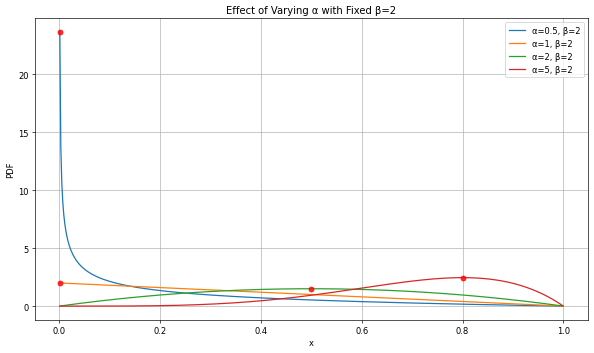

In [62]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=60)

x = np.linspace(0.001, 0.999, 500)
fixed_beta = 2 # Keeping beta constant

# Varying alpha values
alpha_values = [0.5, 1, 2, 5]

for alpha_val in alpha_values:
    y = beta.pdf(x, alpha_val, fixed_beta)
    ax.plot(x, y, label=f'α={alpha_val}, β={fixed_beta}')

    # Add mode markers
    modes = get_beta_mode(alpha_val, fixed_beta)
    if modes and modes != [-1] and isinstance(modes, list):
        for mode_val in modes:
            if mode_val == 0:
                ax.plot(0.001, beta.pdf(0.001, alpha_val, fixed_beta), 'o', color='red', markersize=6, alpha=0.8) # Mark at start
            elif mode_val == 1:
                ax.plot(0.999, beta.pdf(0.999, alpha_val, fixed_beta), 'o', color='red', markersize=6, alpha=0.8) # Mark at end
            else:
                ax.plot(mode_val, beta.pdf(mode_val, alpha_val, fixed_beta), 'o', color='red', markersize=6, alpha=0.8)

ax.set_title(f'Effect of Varying α with Fixed β={fixed_beta}')
ax.set_xlabel('x') ; ax.set_ylabel('PDF')
ax.legend() ; ax.grid(True) ; plt.tight_layout() ; plt.show()

#### Function to Sample from Multiple Beta Distributions

This function allows to draw random samples from a list of specified Beta distributions, providing a way to generate data based on different Beta distribution parameters.

In [65]:
from scipy.stats import beta
import numpy as np

def sample_beta_distributions(beta_params_list, num_samples):
    """
    Samples random values from a list of Beta distributions.

    Args:
        beta_params_list (list): A list of tuples, where each tuple is (alpha, beta) defining a Beta distribution.
        num_samples (int): The number of samples to draw from each distribution.

    Returns:
        list: A list of NumPy arrays, where each array contains 'num_samples'
              random values from the corresponding Beta distribution.
    """
    all_samples = []
    for alpha, beta_val in beta_params_list:
        samples = beta.rvs(alpha, beta_val, size=num_samples)
        all_samples.append(samples)
    return all_samples

#### Demonstration of Beta Distribution Sampling

We'll sample 1000 values from a few different Beta distributions, including some of the parameter pairs we've already visualized.


Statistics for α=0.5, β=0.5 (first 10 samples):
[0.82551862 0.9991202  0.98903038 0.06438664 0.66496827 0.4219967
 0.31228749 0.53096286 0.87219741 0.04734314]
Mean: 0.4974, Median: 0.4918

Statistics for α=2, β=5 (first 10 samples):
[0.21493389 0.44677015 0.17251016 0.31768504 0.36783154 0.22556846
 0.03278445 0.4056314  0.26074482 0.38408109]
Mean: 0.2875, Median: 0.2599

Statistics for α=1, β=1 (first 10 samples):
[0.37439763 0.22833498 0.26861285 0.545177   0.30468834 0.60921318
 0.36751636 0.42074623 0.9784877  0.06889745]
Mean: 0.4986, Median: 0.4956

Statistics for α=5, β=2 (first 10 samples):
[0.5795549  0.88408004 0.48954861 0.86795256 0.54980714 0.69499853
 0.88087867 0.87649644 0.71571678 0.81015452]
Mean: 0.7206, Median: 0.7427


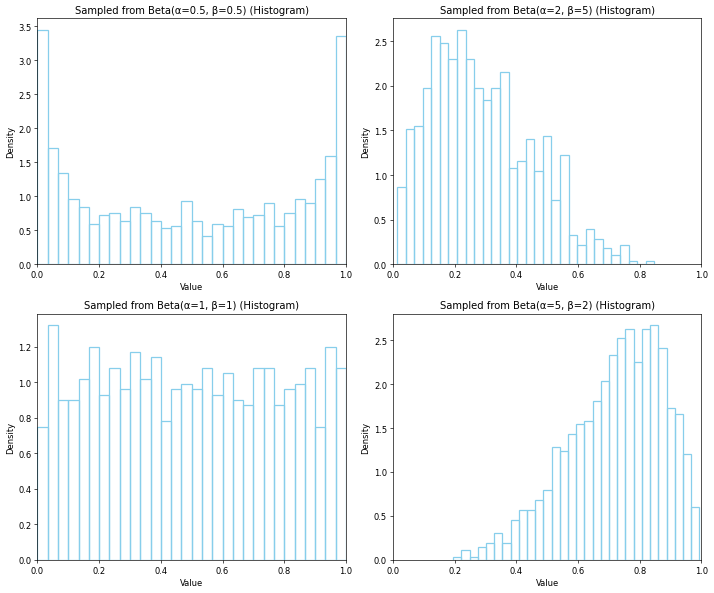

In [66]:
sample_params = [(0.5, 0.5), (2, 5), (1, 1), (5, 2)]
num_samples_per_dist = 1000

sampled_data = sample_beta_distributions(sample_params, num_samples_per_dist)

# Print basic statistics for the first few samples
for i, samples in enumerate(sampled_data):
    alpha, beta_val = sample_params[i]
    print(f"\nStatistics for α={alpha}, β={beta_val} (first 10 samples):\n{samples[:10]}")
    print(f"Mean: {np.mean(samples):.4f}, Median: {np.median(samples):.4f}")

# Optional: You can also plot histograms of the sampled data to see their distributions
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for kdeplot

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=60)
axes = axes.flatten()

for i, samples in enumerate(sampled_data):
    alpha, beta_val = sample_params[i]
    # Use hist for histogram visualization with light contours and no filling
    axes[i].hist(samples, bins=30, density=True, facecolor='none', edgecolor='skyblue', linewidth=1.5)
    axes[i].set_title(f'Sampled from Beta(α={alpha}, β={beta_val}) (Histogram)')
    axes[i].set_xlabel('Value') ; axes[i].set_ylabel('Density')
    axes[i].set_xlim(0, 1)

plt.tight_layout() ; plt.show()

### Bayesian Modeling of Poisson Likelihood with Exponential Prior

We explore the process of deriving the posterior distribution for a parameter $\lambda$ using Bayesian inference. We are given an exponential prior distribution for $\lambda$ and a Poisson likelihood function for our observations.

#### Prior Distribution for $\lambda$

The prior distribution for the parameter $\lambda$ is given as Exponential with rate parameter $a > 0$, denoted $\lambda \sim \text{Exp}(a)$. The pdf of an exponential distribution is $\pi(\lambda) = a \cdot e^{-a\lambda}$ for $\lambda \ge 0$.

When considering proportionality for Bayesian inference, we can ignore multiplicative constants that do not depend on $\lambda$. Therefore, the prior, up to a constant of proportionality, is $\pi(\lambda) \propto e^{-a\lambda}$.

In [ ]:
import numpy as np

# Define a sample rate parameter for the prior
a = 0.5

def proportional_prior(lambda_val, a_val):
    """Calculates the proportional prior density for lambda."""
    return np.exp(-a_val * lambda_val)

# Example usage
lambda_test = np.linspace(0.1, 5, 10)
prior_values = proportional_prior(lambda_test, a)

Sample lambda values: [0.1        0.64444444 1.18888889 1.73333333 2.27777778 2.82222222
 3.36666667 3.91111111 4.45555556 5.        ]
Proportional prior values (for a=0.5): [0.95122942 0.72453716 0.55186907 0.42035038 0.32017457 0.24387216
 0.18575376 0.14148585 0.10776765 0.082085  ]


#### Likelihood Function for Observations $X_1, \dots, X_n$

Conditional on the parameter $\lambda$, the observations $X_1, \dots, X_n$ are assumed to be i.i.d. according to a Poisson distribution with mean $\lambda$, denoted $X_i \sim \text{Poiss}(\lambda)$. The pmf for a single observation $X_i$ is $P(X_i | \lambda) = \frac{e^{-\lambda} \lambda^{X_i}}{X_i!}$. Ignoring terms that do not depend on $\lambda$ (like $X_i!$), the likelihood for a single observation, up to proportionality, is $L(X_i | \lambda) \propto e^{-\lambda} \lambda^{X_i}$. For $n$ i.i.d. observations $X_1, \dots, X_n$, the joint likelihood is the product of individual likelihoods $L(X_1, \dots, X_n | \lambda) = \prod_{i=1}^{n} L(X_i | \lambda)$. Substituting the proportional form for $L(X_i | \lambda)$
- $L(X_1, \dots, X_n | \lambda) \propto \prod_{i=1}^{n} (e^{-\lambda} \lambda^{X_i}) \propto e^{-n\lambda} \lambda^{\sum_{i=1}^{n} X_i}$

In [ ]:
# Sample observations (e.g., counts from a Poisson process)
observations = np.array([2, 5, 3, 4, 1])
n = len(observations)
sum_x = np.sum(observations)

def proportional_likelihood(lambda_val, n_obs, sum_x_obs):
    """Calculates the proportional likelihood for n Poisson observations."""
    return np.exp(-n_obs * lambda_val) * (lambda_val**sum_x_obs)

# Example usage
lambda_test = np.linspace(0.1, 5, 10)
likelihood_values = proportional_likelihood(lambda_test, n, sum_x)

Observations (X): [2 5 3 4 1]
Number of observations (n): 5
Sum of observations (sum(X)): 15
Sample lambda values: [0.1        0.64444444 1.18888889 1.73333333 2.27777778 2.82222222
 3.36666667 3.91111111 4.45555556 5.        ]
Proportional likelihood values: [6.06530660e-16 5.47506061e-05 3.51139433e-02 6.59698997e-01
 2.60938808e+00 4.27061498e+00 3.95710895e+00 2.46395313e+00
 1.14396303e+00 4.23826412e-01]


#### Posterior Distribution (Proportional Form)

According to Bayes' theorem, the posterior distribution is proportional to the product of the likelihood and the prior $\pi(\lambda | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | \lambda) \cdot \pi(\lambda)$. Substituting the proportional forms of the likelihood and prior $\pi(\lambda | X_1, \dots, X_n) \propto (e^{-n\lambda} \lambda^{\sum_{i=1}^{n} X_i}) \cdot (e^{-a\lambda})$

Combining the exponential terms
- $\pi(\lambda | X_1, \dots, X_n) \propto e^{-(a+n)\lambda} \lambda^{\sum_{i=1}^{n} X_i}$

This form of the posterior distribution is recognizable as a Gamma distribution, specifically $\text{Gamma}(\alpha = \sum_{i=1}^{n} X_i + 1, \beta = a + n)$.

This means that if our prior for $\lambda$ is Exponential and our data follows a Poisson distribution, the posterior distribution for $\lambda$ is a Gamma distribution. This demonstrates a conjugate prior relationship.

In [ ]:
def proportional_posterior(lambda_val, a_val, n_obs, sum_x_obs):
    """Calculates the proportional posterior density for lambda."""
    # Posterior is proportional to prior * likelihood
    # proportional_prior(lambda_val, a_val) * proportional_likelihood(lambda_val, n_obs, sum_x_obs)
    return np.exp(-(a_val + n_obs) * lambda_val) * (lambda_val**sum_x_obs)

# Example usage with previously defined `a`, `n`, `sum_x`, and `lambda_test`
posterior_values = proportional_posterior(lambda_test, a, n, sum_x)

Sample lambda values: [0.1        0.64444444 1.18888889 1.73333333 2.27777778 2.82222222
 3.36666667 3.91111111 4.45555556 5.        ]
Proportional posterior values: [5.76949810e-16 3.96688489e-05 1.93782994e-02 2.77304727e-01
 8.35459718e-01 1.04148411e+00 7.35047880e-01 3.48614507e-01
 1.23282205e-01 3.47897904e-02]


#### The Gamma Distribution

The Gamma distribution is a two-parameter family of continuous probability distributions. It is commonly used as a conjugate prior for the rate parameter of a Poisson distribution or the precision parameter of a normal distribution.

Its pdf is given by $f(x; \alpha, \beta) = \frac{\beta^{\alpha} x^{\alpha-1} e^{-\beta x}}{\Gamma(\alpha)}$ for $x > 0$, where $\alpha > 0$ is the shape parameter, $\beta > 0$ is the rate parameter (or inverse scale parameter), and $\Gamma(\alpha)$ is the Gamma function.



#### Simplified Gamma Distribution for Proportionality

For Bayesian inference, when considering proportionality, we can ignore the normalization constant $\frac{\beta^{\alpha}}{\Gamma(\alpha)}$, as it does not depend on the variable $x$. Therefore, the Gamma distribution, up to a constant of proportionality, simplifies to
- $f(x; \alpha, \beta) \propto x^{\alpha-1} e^{-\beta x}$

#### Likelihood Function
The proportional form of the likelihood function for $n$ i.i.d. Poisson observations $X_1, \dots, X_n$$X_1, \dots, X_n$ given the parameter $\lambda$ is:

$L(X_1, \dots, X_n | \lambda) \propto e^{-n\lambda} \lambda^{\sum_{i=1}^{n} X_i}$$L(X_1, \dots, X_n | \lambda) \propto e^{-n\lambda} \lambda^{\sum_{i=1}^{n} X_i}$

#### Posterior Distribution
The final posterior distribution for $\lambda$ given the observations $X_1, \dots, X_n$$X_1, \dots, X_n$ is proportional to
- $\pi(\lambda | X_1, \dots, X_n) \propto e^{-(a+n)\lambda} \lambda^{\sum_{i=1}^{n} X_i}$ $\quad$ $\pi(\lambda | X_1, \dots, X_n) \propto e^{-(a+n)\lambda} \lambda^{\sum_{i=1}^{n} X_i}$

We can identify the parameters of the posterior Gamma distribution
- Shape parameter $\alpha = \sum_{i=1}^{n} X_i + 1$, Rate parameter $\beta = a + n$


Proportional Gamma PDF values (using posterior parameters): [5.76949810e-16 3.96688489e-05 1.93782994e-02 2.77304727e-01
 8.35459718e-01 1.04148411e+00 7.35047880e-01 3.48614507e-01
 1.23282205e-01 3.47897904e-02] 



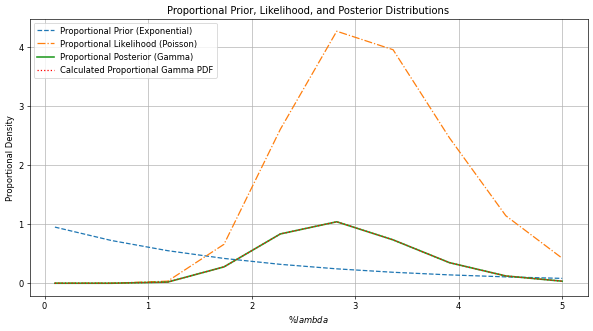

In [ ]:
import matplotlib.pyplot as plt

# Calculate the parameters for the posterior Gamma distribution
alpha_posterior = sum_x + 1
beta_posterior = a + n

def proportional_gamma_pdf(x, alpha, beta):
    """Calculates the proportional Gamma PDF."""
    # f(x) ~ x^(alpha - 1) * e^(-beta * x)
    return (x**(alpha - 1)) * np.exp(-beta * x)

# Calculate proportional Gamma PDF values using the posterior parameters
proportional_gamma_values = proportional_gamma_pdf(lambda_test, alpha_posterior, beta_posterior)

### Bayesian Modeling of Poisson Likelihood with Exponential Prior

We explore the process of deriving the posterior distribution for a parameter $\lambda$ using Bayesian inference. We are given an exponential prior distribution for $\lambda$ and a Poisson likelihood function for our observations.

#### **Prior Exp Distribution for $\lambda$ and Poiss observations**

The prior distribution for the parameter $\lambda$ is given as Exponential with rate parameter $a > 0$, denoted $\lambda \sim \text{Exp}(a)$. The pdf of an exponential distribution is $\pi(\lambda) = a \cdot e^{-a\lambda}$ for $\lambda \ge 0$.

When considering proportionality for Bayesian inference, we can ignore multiplicative constants that do not depend on $\lambda$. Therefore, the prior, up to a constant of proportionality, is $\pi(\lambda) \propto e^{-a\lambda}$.

In [ ]:
import numpy as np

# Define a sample rate parameter for the prior
a = 0.5

def proportional_prior(lambda_val, a_val):
    """Calculates the proportional prior density for lambda."""
    return np.exp(-a_val * lambda_val)

# Example usage
lambda_test = np.linspace(0.1, 5, 10)
prior_values = proportional_prior(lambda_test, a)

Sample lambda values: [0.1        0.64444444 1.18888889 1.73333333 2.27777778 2.82222222
 3.36666667 3.91111111 4.45555556 5.        ]
Proportional prior values (for a=0.5): [0.95122942 0.72453716 0.55186907 0.42035038 0.32017457 0.24387216
 0.18575376 0.14148585 0.10776765 0.082085  ]


#### Likelihood Function for Observations $X_1, \dots, X_n$

Conditional on the parameter $\lambda$, the observations $X_1, \dots, X_n$ are assumed to be i.i.d. according to a Poisson distribution with mean $\lambda$, denoted $X_i \sim \text{Poiss}(\lambda)$. The pmf for a single observation $X_i$ is $P(X_i | \lambda) = \frac{e^{-\lambda} \lambda^{X_i}}{X_i!}$. Ignoring terms that do not depend on $\lambda$ (like $X_i!$), the likelihood for a single observation, up to proportionality, is $L(X_i | \lambda) \propto e^{-\lambda} \lambda^{X_i}$. For $n$ i.i.d. observations $X_1, \dots, X_n$, the joint likelihood is the product of individual likelihoods $L(X_1, \dots, X_n | \lambda) = \prod_{i=1}^{n} L(X_i | \lambda)$. Substituting the proportional form for $L(X_i | \lambda)$
- $L(X_1, \dots, X_n | \lambda) \propto \prod_{i=1}^{n} (e^{-\lambda} \lambda^{X_i}) \propto e^{-n\lambda} \lambda^{\sum_{i=1}^{n} X_i}$

In [ ]:
# Sample observations (e.g., counts from a Poisson process)
observations = np.array([2, 5, 3, 4, 1])
n = len(observations)
sum_x = np.sum(observations)

def proportional_likelihood(lambda_val, n_obs, sum_x_obs):
    """Calculates the proportional likelihood for n Poisson observations."""
    return np.exp(-n_obs * lambda_val) * (lambda_val**sum_x_obs)

# Example usage
lambda_test = np.linspace(0.1, 5, 10)
likelihood_values = proportional_likelihood(lambda_test, n, sum_x)

Observations (X): [2 5 3 4 1]
Number of observations (n): 5
Sum of observations (sum(X)): 15
Sample lambda values: [0.1        0.64444444 1.18888889 1.73333333 2.27777778 2.82222222
 3.36666667 3.91111111 4.45555556 5.        ]
Proportional likelihood values: [6.06530660e-16 5.47506061e-05 3.51139433e-02 6.59698997e-01
 2.60938808e+00 4.27061498e+00 3.95710895e+00 2.46395313e+00
 1.14396303e+00 4.23826412e-01]


#### **Posterior Distribution (Proportional Form, Exp prior with Poiss observations)**

According to Bayes' theorem, the posterior distribution is proportional to the product of the likelihood and the prior $\pi(\lambda | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | \lambda) \cdot \pi(\lambda)$. Substituting the proportional forms of the likelihood and prior $\pi(\lambda | X_1, \dots, X_n) \propto (e^{-n\lambda} \lambda^{\sum_{i=1}^{n} X_i}) \cdot (e^{-a\lambda})$

Combining the exponential terms
- $\pi(\lambda | X_1, \dots, X_n) \propto e^{-(a+n)\lambda} \lambda^{\sum_{i=1}^{n} X_i}$

This form of the posterior distribution is recognizable as a Gamma distribution, specifically $\text{Gamma}(\alpha = \sum_{i=1}^{n} X_i + 1, \beta = a + n)$.

This means that if our prior for $\lambda$ is Exponential and our data follows a Poisson distribution, the posterior distribution for $\lambda$ is a Gamma distribution. This demonstrates a conjugate prior relationship.

In [ ]:
def proportional_posterior(lambda_val, a_val, n_obs, sum_x_obs):
    """Calculates the proportional posterior density for lambda."""
    # Posterior is proportional to prior * likelihood
    # proportional_prior(lambda_val, a_val) * proportional_likelihood(lambda_val, n_obs, sum_x_obs)
    return np.exp(-(a_val + n_obs) * lambda_val) * (lambda_val**sum_x_obs)

# Example usage with previously defined `a`, `n`, `sum_x`, and `lambda_test`
posterior_values = proportional_posterior(lambda_test, a, n, sum_x)

Sample lambda values: [0.1        0.64444444 1.18888889 1.73333333 2.27777778 2.82222222
 3.36666667 3.91111111 4.45555556 5.        ]
Proportional posterior values: [5.76949810e-16 3.96688489e-05 1.93782994e-02 2.77304727e-01
 8.35459718e-01 1.04148411e+00 7.35047880e-01 3.48614507e-01
 1.23282205e-01 3.47897904e-02]


#### The Gamma Distribution

The Gamma distribution is a two-parameter family of continuous probability distributions. It is commonly used as a conjugate prior for the rate parameter of a Poisson distribution or the precision parameter of a normal distribution.

Its pdf is given by $f(x; \alpha, \beta) = \frac{\beta^{\alpha} x^{\alpha-1} e^{-\beta x}}{\Gamma(\alpha)}$ for $x > 0$, where $\alpha > 0$ is the shape parameter, $\beta > 0$ is the rate parameter (or inverse scale parameter), and $\Gamma(\alpha)$ is the Gamma function.



#### **Simplified Gamma Distribution for Proportionality**

For Bayesian inference, when considering proportionality, we can ignore the normalization constant $\frac{\beta^{\alpha}}{\Gamma(\alpha)}$, as it does not depend on the variable $x$. Therefore, the Gamma distribution, up to a constant of proportionality, simplifies to
- $f(x; \alpha, \beta) \propto x^{\alpha-1} e^{-\beta x}$

#### Likelihood Function
The proportional form of the likelihood function for $n$ i.i.d. Poisson observations $X_1, \dots, X_n$$X_1, \dots, X_n$ given the parameter $\lambda$ is:

$L(X_1, \dots, X_n | \lambda) \propto e^{-n\lambda} \lambda^{\sum_{i=1}^{n} X_i}$$L(X_1, \dots, X_n | \lambda) \propto e^{-n\lambda} \lambda^{\sum_{i=1}^{n} X_i}$

#### **Posterior Gamma Distribution**
The final posterior distribution for $\lambda$ given the observations $X_1, \dots, X_n$$X_1, \dots, X_n$ is proportional to
- $\pi(\lambda | X_1, \dots, X_n) \propto e^{-(a+n)\lambda} \lambda^{\sum_{i=1}^{n} X_i}$ $\quad$ $\pi(\lambda | X_1, \dots, X_n) \propto e^{-(a+n)\lambda} \lambda^{\sum_{i=1}^{n} X_i}$

We can identify the parameters of the posterior Gamma distribution
- Shape parameter $\alpha = \sum_{i=1}^{n} X_i + 1$, Rate parameter $\beta = a + n$


Proportional Gamma PDF values (using posterior parameters): [5.76949810e-16 3.96688489e-05 1.93782994e-02 2.77304727e-01
 8.35459718e-01 1.04148411e+00 7.35047880e-01 3.48614507e-01
 1.23282205e-01 3.47897904e-02] 



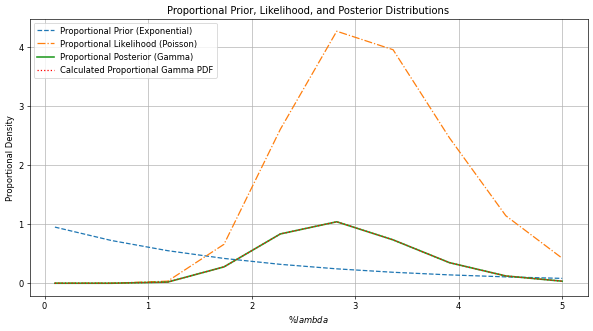

In [ ]:
import matplotlib.pyplot as plt

# Calculate the parameters for the posterior Gamma distribution
alpha_posterior = sum_x + 1
beta_posterior = a + n

def proportional_gamma_pdf(x, alpha, beta):
    """Calculates the proportional Gamma PDF."""
    # f(x) ~ x^(alpha - 1) * e^(-beta * x)
    return (x**(alpha - 1)) * np.exp(-beta * x)

# Calculate proportional Gamma PDF values using the posterior parameters
proportional_gamma_values = proportional_gamma_pdf(lambda_test, alpha_posterior, beta_posterior)

In [ ]:
print(f"Sample lambda values: {lambda_test}")
print(f"Proportional likelihood values: {likelihood_values}")
print(f"Proportional posterior values: {posterior_values}")

Sample lambda values: [0.1        0.64444444 1.18888889 1.73333333 2.27777778 2.82222222
 3.36666667 3.91111111 4.45555556 5.        ]
Proportional likelihood values: [6.06530660e-16 5.47506061e-05 3.51139433e-02 6.59698997e-01
 2.60938808e+00 4.27061498e+00 3.95710895e+00 2.46395313e+00
 1.14396303e+00 4.23826412e-01]
Proportional posterior values: [5.76949810e-16 3.96688489e-05 1.93782994e-02 2.77304727e-01
 8.35459718e-01 1.04148411e+00 7.35047880e-01 3.48614507e-01
 1.23282205e-01 3.47897904e-02]


### Beta Distribution Conjugacy with Bernoulli Likelihood

Explore the Beta-Bernoulli conjugate prior relationship. Our parameter of interest is $p$, representing the probability of success in a Bernoulli trial. We assume a Beta prior distribution for $p$ and Bernoulli likelihood for our observations.

#### **Prior Beta Distribution for $p$**

The prior distribution for the parameter $p$ is given as a Beta distribution with shape parameters $a$ and $b$, denoted $p \sim \text{Beta}(a, b)$. The PDF of a Beta distribution is $\pi(p) = \frac{p^{a-1} (1-p)^{b-1}}{B(a,b)}$ for $0 \le p \le 1$, where $B(a,b)$ is the Beta function.

For Bayesian inference, we can consider the proportional form by ignoring the normalization constant $B(a,b)$: $\pi(p) \propto p^{a-1} (1-p)^{b-1}$.

In [ ]:
import numpy as np

# Define sample parameters for the Beta prior
a_prior = 2
b_prior = 2

def proportional_beta_prior(p_val, a, b):
    """Calculates the proportional prior density for p (Beta distribution)."""
    # Ensure p_val is within (0, 1) to avoid log(0) or similar issues
    p_val = np.clip(p_val, 1e-10, 1 - 1e-10)
    return (p_val**(a - 1)) * ((1 - p_val)**(b - 1))

# Example usage
p_test = np.linspace(0.01, 0.99, 100) # p must be between 0 and 1
prior_beta_values = proportional_beta_prior(p_test, a_prior, b_prior)

Prior Beta parameters: a=2, b=2


#### Likelihood Function for Observations $X_1, \dots, X_n$

Conditional on the parameter $p$, the observations $X_1, \dots, X_n$ are assumed to be i.i.d. according to a Bernoulli distribution with parameter $p$, denoted $X_i \sim \text{Ber}(p)$. The probability mass function (PMF) for a single observation $X_i$ is $P(X_i | p) = p^{X_i} (1-p)^{1-X_i}$.

For $n$ i.i.d. observations, the joint likelihood is the product of individual likelihoods:
$L(X_1, \dots, X_n | p) = \prod_{i=1}^{n} P(X_i | p)$
$L(X_1, \dots, X_n | p) = \prod_{i=1}^{n} (p^{X_i} (1-p)^{1-X_i})$
$L(X_1, \dots, X_n | p) = p^{\sum X_i} (1-p)^{\sum (1-X_i)}$
$L(X_1, \dots, X_n | p) = p^{\sum X_i} (1-p)^{n - \sum X_i}$

Let $S_n = \sum X_i$ be the number of successes. Then the likelihood is
- $L(X_1, \dots, X_n | p) = p^{S_n} (1-p)^{n - S_n}$

In [ ]:
# Sample Bernoulli observations (0 for failure, 1 for success)
observations_bernoulli = np.array([1, 0, 1, 1, 0, 1, 1, 0, 1, 1])
n_bernoulli = len(observations_bernoulli)
sum_x_bernoulli = np.sum(observations_bernoulli) # Number of successes

def proportional_bernoulli_likelihood(p_val, n_obs, sum_x_obs):
    """Calculates the proportional likelihood for n Bernoulli observations."""
    # Ensure p_val is within (0, 1) to avoid issues with powers of 0 or 1
    p_val = np.clip(p_val, 1e-10, 1 - 1e-10)
    return (p_val**sum_x_obs) * ((1 - p_val)**(n_obs - sum_x_obs))

# Example usage
likelihood_bernoulli_values = proportional_bernoulli_likelihood(p_test, n_bernoulli, sum_x_bernoulli)

Bernoulli Observations: [1 0 1 1 0 1 1 0 1 1]
Number of observations (n): 10
Number of successes (sum(X)): 7


#### **Posterior Beta Distribution (Proportional Form, Beta prior and Ber observations)**

According to Bayes' theorem, the posterior distribution is proportional to the product of the likelihood and the prior $\pi(p | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | p) \cdot \pi(p)$.

Substituting the proportional forms of the likelihood and prior:
$\pi(p | X_1, \dots, X_n) \propto (p^{S_n} (1-p)^{n - S_n}) \cdot (p^{a-1} (1-p)^{b-1})$. Combining the terms with $p$ and $(1-p)$
$\pi(p | X_1, \dots, X_n) \propto p^{(S_n + a - 1)} (1-p)^{((n - S_n) + b - 1)}$

This form of the posterior distribution is recognizable as a Beta distribution, specifically
- $\text{Beta}(\alpha_{\text{post}} = S_n + a, \beta_{\text{post}} = n - S_n + b)$.

This demonstrates that if our prior for $p$ is Beta and our data follows a Bernoulli distribution, the posterior distribution for $p$ is also a Beta distribution, highlighting a conjugate prior relationship.

In [ ]:
def proportional_beta_posterior(p_val, a_prior, b_prior, n_obs, sum_x_obs):
    """ Calculates the proportional posterior density for p (Beta dist.) """
    # Posterior is proportional to prior * likelihood
    # p^(sum_x_obs + a_prior - 1) * (1 - p)^(n_obs - sum_x_obs + b_prior - 1)
    p_val = np.clip(p_val, 1e-10, 1 - 1e-10)
    return (p_val**(sum_x_obs + a_prior - 1)) * ((1 - p_val)**(n_obs - sum_x_obs + b_prior - 1))

# Example usage with previously defined `a_prior`, `b_prior`, `n_bernoulli`, `sum_x_bernoulli`, and `p_test`
posterior_beta_values = proportional_beta_posterior(p_test, a_prior, b_prior, n_bernoulli, sum_x_bernoulli)

Sample p values: [0.01       0.01989899 0.02979798 0.03969697 0.04959596]...
Proportional Beta Posterior values (first 5): [9.60596010e-17 2.26846248e-14 5.50735751e-13 5.24435453e-12
 2.98678166e-11]...


Posterior Beta parameters: alpha=9, beta=5


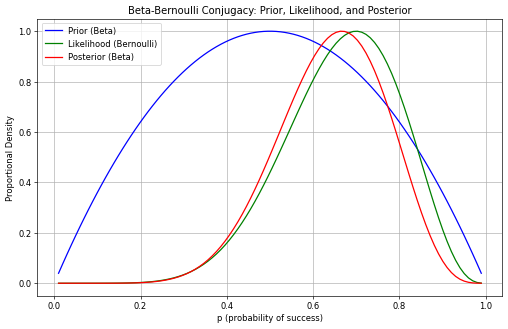

In [ ]:
import matplotlib.pyplot as plt

# Calculate the parameters for the posterior Beta distribution
alpha_posterior_beta = sum_x_bernoulli + a_prior
beta_posterior_beta = n_bernoulli - sum_x_bernoulli + b_prior

print(f"Posterior Beta parameters: alpha={alpha_posterior_beta}, beta={beta_posterior_beta}")

def proportional_beta_pdf_check(x, alpha, beta):
    """Calculates the proportional Beta PDF using the posterior parameters."""
    # f(x) ~ x^(alpha - 1) * (1 - x)^(beta - 1)
    x = np.clip(x, 1e-10, 1 - 1e-10)
    return (x**(alpha - 1)) * ((1 - x)**(beta - 1))

# Calculate proportional Beta PDF values using the posterior parameters
proportional_beta_pdf_check_values = proportional_beta_pdf_check(p_test, alpha_posterior_beta, beta_posterior_beta)

# Verify that the calculated posterior values match the Beta PDF with derived parameters
# We'll normalize both for visual comparison, but mathematically they should be proportional
# For simplicity, we just compare the raw proportional values directly
# assert np.allclose(posterior_beta_values, proportional_beta_pdf_check_values)

### Gaussian Conjugacy with Gaussian Observations

Explore the Bayesian inference for a Gaussian likelihood with a Gaussian prior. Our parameter of interest is the mean $\theta$ of the Gaussian distribution. We assume a Gaussian prior for $\theta$ and Gaussian likelihood for our observations.

#### **Prior Gaussian Distribution for $\theta$**

The prior distribution for the parameter $\theta$ is given as a Gaussian (Normal) distribution with mean $\mu$ and variance $\tau^2$, denoted $\theta \sim N(\mu, \tau^2)$. For simplicity, we'll assume $\tau^2 = 1$. The pdf of a Gaussian distribution is $\pi(\theta) = \frac{1}{\sqrt{2\pi \tau^2}} e^{-\frac{1}{2\tau^2}(\theta - \mu)^2}$. For Bayesian inference, we can consider the proportional form by ignoring the normalization constant
- $\frac{1}{\sqrt{2\pi \tau^2}}$:
$\pi(\theta) \propto e^{-\frac{1}{2\tau^2}(\theta - \mu)^2}$

In [ ]:
import numpy as np

# Define sample parameters for the Gaussian prior
mu_prior = 0 # Prior mean
sigma_sq_prior = 1 # Prior variance

def proportional_gaussian_prior(theta_val, mu, sigma_sq):
    """Calculates the proportional prior density for theta (Gaussian distribution)."""
    return np.exp(-0.5 * (theta_val - mu)**2 / sigma_sq)

# Example usage
theta_test = np.linspace(-3, 3, 100) # Range for theta
prior_gaussian_values = proportional_gaussian_prior(theta_test, mu_prior, sigma_sq_prior)

print(f"Prior Gaussian parameters: mu={mu_prior}, sigma^2={sigma_sq_prior}")

Prior Gaussian parameters: mu=0, sigma^2=1


#### Likelihood Function for Observations $X_1, \dots, X_n$

Conditional on the parameter $\theta$, the observations $X_1, \dots, X_n$ are assumed to be i.i.d. according to a Gaussian distribution with mean $\theta$ and variance $\sigma^2$, denoted $X_i \sim N(\theta, \sigma^2)$. For simplicity, we'll assume $\sigma^2 = 1$.

The pdf for a single observation $X_i$ is $P(X_i | \theta) = \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{1}{2\sigma^2}(X_i - \theta)^2}$.

For $n$ i.i.d. observations, the joint likelihood is the product of individual likelihoods:
$L(X_1, \dots, X_n | \theta) = \prod_{i=1}^{n} P(X_i | \theta)$
$L(X_1, \dots, X_n | \theta) \propto \prod_{i=1}^{n} e^{-\frac{1}{2\sigma^2}(X_i - \theta)^2} \propto e^{-\frac{1}{2\sigma^2} \sum_{i=1}^{n} (X_i - \theta)^2}$. Expanding the sum and ignoring terms that do not depend on $\theta$ (like $\sum X_i^2$), $\sum_{i=1}^{n} (X_i - \theta)^2 = \sum X_i^2 - 2\theta \sum X_i + n\theta^2$
So, $L(X_1, \dots, X_n | \theta) \propto e^{-\frac{1}{2\sigma^2} (-2\theta \sum X_i + n\theta^2)}$
- $L(X_1, \dots, X_n | \theta) \propto e^{\frac{n\bar{X}}{\sigma^2}\theta - \frac{n}{2\sigma^2}\theta^2}$ (where $\bar{X} = \frac{1}{n}\sum X_i$)

In [ ]:
# Sample Gaussian observations
theta_true = 0.5 # True mean of the population
sigma_sq_likelihood = 1 # Variance of the likelihood
n_gaussian = 10 # Number of observations
observations_gaussian = np.random.normal(loc=theta_true, scale=np.sqrt(sigma_sq_likelihood), size=n_gaussian)

sum_x_gaussian = np.sum(observations_gaussian)
mean_x_gaussian = np.mean(observations_gaussian)

def proportional_gaussian_likelihood(theta_val, n_obs, mean_x, sigma_sq):
    """Calculates the proportional likelihood for n Gaussian observations."""
    # Based on the derived proportional form: exp( (n*mean_x/sigma_sq)*theta - (n/(2*sigma_sq))*theta^2 )
    # Or more directly from sum( (Xi - theta)^2 ) ignoring terms not dependent on theta
    return np.exp(-0.5 * n_obs * (mean_x - theta_val)**2 / sigma_sq)

# Example usage
likelihood_gaussian_values = proportional_gaussian_likelihood(theta_test, n_gaussian, mean_x_gaussian, sigma_sq_likelihood)

True mean (theta_true): 0.5
Gaussian Observations (first 5): [ 1.36264882  1.17857944  0.14674912 -0.82055979  0.82668701]...
Number of observations (n): 10
Sum of observations (sum(X)): 9.02
Mean of observations (mean(X)): 0.90


#### **Posterior Gaussian Distribution with Gaussian observations (Proportional Form)**

According to Bayes' theorem, the posterior distribution is proportional to the product of the likelihood and the prior: $\pi(\theta | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | \theta) \cdot \pi(\theta)$. Substituting the proportional forms of the likelihood and prior (and assuming $\tau^2 = \sigma^2 = 1$ for simplicity):
$\pi(\theta | X_1, \dots, X_n) \propto e^{-\frac{1}{2}(\theta - \mu_{\text{prior}})^2} \cdot e^{-\frac{n}{2}(X_i - \theta)^2}$
$\pi(\theta | X_1, \dots, X_n) \propto e^{-\frac{1}{2} [(\theta - \mu_{\text{prior}})^2 + n(\bar{X} - \theta)^2 + C]}$ (where C are terms not depending on $\theta$).

Expanding the exponents and combining terms, the posterior distribution $\pi(\theta | X_1, \dots, X_n)$ will also be a Gaussian distribution, with parameters **Posterior Mean**: $\mu_{\text{post}} = \frac{\frac{\mu_{\text{prior}}}{\tau^2} + \frac{n\bar{X}}{\sigma^2}}{\frac{1}{\tau^2} + \frac{n}{\sigma^2}}$, **Posterior Variance**: $\sigma^2_{\text{post}} = \frac{1}{\frac{1}{\tau^2} + \frac{n}{\sigma^2}}$

In our simplified case, where $\tau^2 = 1$ and $\sigma^2 = 1$, $\mu_{\text{post}} = \frac{\mu_{\text{prior}} + n\bar{X}}{1 + n}$,$\sigma^2_{\text{post}} = \frac{1}{1 + n}$

Posterior Gaussian parameters: mu=0.82, sigma^2=0.09


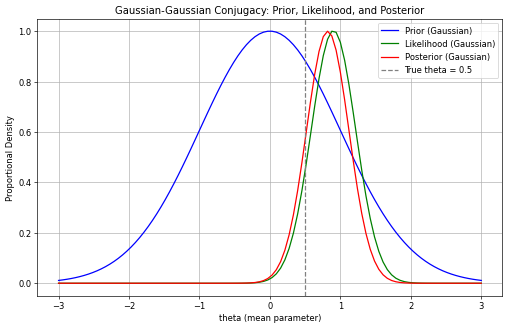

In [ ]:
import matplotlib.pyplot as plt

# Calculate the parameters for the posterior Gaussian distribution
mu_posterior_gaussian = (mu_prior / sigma_sq_prior + n_gaussian * mean_x_gaussian / sigma_sq_likelihood) / (1 / sigma_sq_prior + n_gaussian / sigma_sq_likelihood)
sigma_sq_posterior_gaussian = 1 / (1 / sigma_sq_prior + n_gaussian / sigma_sq_likelihood)

def proportional_gaussian_posterior(theta_val, mu_post, sigma_sq_post):
    """Calculates the proportional posterior density for theta (Gaussian distribution)."""
    return np.exp(-0.5 * (theta_val - mu_post)**2 / sigma_sq_post)

posterior_gaussian_values = proportional_gaussian_posterior(theta_test, mu_posterior_gaussian, sigma_sq_posterior_gaussian)

#### Statistics of the Posterior Gamma Distribution

Using the derived posterior parameters for the Gamma distribution:
- Shape parameter (q0): $\alpha_{\text{posterior}} = \sum_{i=1}^{n} X_i + 1$, and  Rate parameter (lambda0): $\beta_{\text{posterior}} = a + n$

We can calculate the following statistics:

Mean: $\frac{q_0}{\lambda_0} = \frac{\sum X_i + 1}{a + n}$; Median: No closed form ; Mode: $\frac{q_0 - 1}{\lambda_0} = \frac{\sum X_i}{a + n}$ (for $q_0 > 1$) and Variance: $\frac{q_0}{\lambda_0^2} = \frac{\sum X_i + 1}{(a + n)^2}$

In [ ]:
# Calculate the parameters for the posterior Gamma distribution
alpha_posterior = sum_x + 1
beta_posterior = a + n

# Calculate statistics for the posterior Gamma distribution
posterior_mean_gamma = alpha_posterior / beta_posterior
posterior_mode_gamma = (alpha_posterior - 1) / beta_posterior if alpha_posterior > 1 else -1 # Mode is only for alpha > 1
posterior_variance_gamma = alpha_posterior / (beta_posterior**2)

Posterior Gamma Mean: 2.9091
Posterior Gamma Median: -1 (no closed form)
Posterior Gamma Mode: 2.7273
Posterior Gamma Variance: 0.5289


In [ ]:
import numpy as np
from scipy.stats import norm

# Define sample observations and improper prior parameter 'a'
# For demonstration, let's use some arbitrary values.
observations_improper = np.array([1.2, 0.8, 1.5, 0.9, 1.1])
a_improper = 0.1 # Prior parameter 'a'

n_improper = len(observations_improper)
sum_x_improper = np.sum(observations_improper)

# Calculate parameters for the quadratic polynomial in lambda
alpha_quad = -n_improper / 2
beta_quad = sum_x_improper - a_improper

# Compute posterior statistics
posterior_mean_improper = -beta_quad / (2 * alpha_quad)
posterior_variance_improper = -1 / (2 * alpha_quad)
posterior_std_improper = np.sqrt(posterior_variance_improper)

# Calculate the 0.025 quantile (2.5th percentile) for a Gaussian distribution
q_0_025_improper = posterior_mean_improper + norm.ppf(0.025) * posterior_std_improper

Observations: [1.2 0.8 1.5 0.9 1.1]
Number of observations (n): 5
Sum of observations (SumXi): 5.50
Prior parameter 'a': 0.1

Posterior Mean: 1.0800
Posterior Variance: 0.2000
Posterior 0.025 Quantile: 0.2035


#### Gaussian Likelihood with Improper Gaussian Prior

Derive the posterior distribution for the mean parameter $\lambda$ given an improper prior and Gaussian observations.

Given:
1.  Improper Prior Distribution: $\pi(\lambda) \propto e^{-a\lambda}$ for $\lambda \in \mathbb{R}$, where $a \ge 0$.
2.  Likelihood Function: $X_i \sim N(\lambda, 1)$ (Gaussian with mean $\lambda$ and known variance $1$), for $i=1, \dots, n$ i.i.d. observations.
    *   $L(X_1, \dots, X_n | \lambda) \propto e^{-\frac{1}{2} \sum_{i=1}^{n} (X_i - \lambda)^2}$

1.  Define the proportional forms of the prior and likelihood.
2.  Apply Bayes' theorem to find the proportional form of the posterior: $\pi(\lambda | X_1, \dots, X_n) \propto L(X_1, \dots, X_n | \lambda) \cdot \pi(\lambda)$.
3.  Expand and combine terms in the exponent to identify the quadratic form $A\lambda^2 + B\lambda + C$.
4.  From the quadratic form, determine the mean and variance of the resulting Gaussian posterior distribution.

#### Gaussian Likelihood with Exponential Prior

Let's derive the posterior distribution for the mean parameter $\lambda$ given an exponential prior and Gaussian observations.

**Given**:

1.) Prior Distribution: $\lambda \sim \text{Exp}(a)$ (Exponential with rate $a > 0$). $\pi(\lambda) \propto e^{-a\lambda}$ for $\lambda \ge 0$. & 2.) Likelihood Function: $X_i \sim N(\lambda, 1)$ (Gaussian with mean $\lambda$ and known variance $1$), for $i=1, \dots, n$ i.i.d. observations.
$L(X_1, \dots, X_n | \lambda) \propto e^{-\frac{1}{2} \sum_{i=1}^{n} (X_i - \lambda)^2}$

**Compute Statistics**:

3.) Posterior Distribution (proportional form):
Applying Bayes' theorem:
$\pi(\lambda | X_1, \dots, X_n) \sim N\left(\mu_{\text{post}} = \frac{\sum X_i - a}{n}, \sigma_{\text{post}}^2 = \frac{1}{n}\right)$

For a Gaussian distribution, the mean, median, and mode are all equal to the mean parameter.
- Mean: $\mu_{\text{post}} = \frac{\sum X_i - a}{n}$
- Median: $\mu_{\text{post}} = \frac{\sum X_i - a}{n}$
- Mode: $\mu_{\text{post}} = \frac{\sum X_i - a}{n}$
- Variance: $\sigma_{\text{post}}^2 = \frac{1}{n}$

**Note**: While the prior is defined for $\lambda \ge 0$, the derived posterior is a Gaussian distribution over all real numbers. The condition $a < \sum X_i$ ensures that the mean of this Gaussian is positive, making it more consistent with the prior's support. For a strictly exponential prior, the posterior would technically be a truncated Gaussian.

In [ ]:
import numpy as np

# Define sample observations and prior parameter 'a'
# For demonstration, let's use some arbitrary values.
observations_gaussian_exp_prior = np.array([2.1, 1.8, 2.5, 1.9, 2.3])
a_exp_prior = 0.5 # Prior parameter 'a'

n_gaussian_exp_prior = len(observations_gaussian_exp_prior)
sum_x_gaussian_exp_prior = np.sum(observations_gaussian_exp_prior)

# Ensure the condition a < SumXi for a positive mean
if not (a_exp_prior < sum_x_gaussian_exp_prior):
    print(f"Warning: 'a' ({a_exp_prior}) is not less than SumXi ({sum_x_gaussian_exp_prior}). "
          "The posterior mean will be non-positive, which may be inconsistent with an Exponential prior for lambda >= 0.")

# Calculate posterior statistics for the Gaussian distribution
posterior_mean_gaussian_exp_prior = (sum_x_gaussian_exp_prior - a_exp_prior) / n_gaussian_exp_prior
posterior_variance_gaussian_exp_prior = 1 / n_gaussian_exp_prior
posterior_std_gaussian_exp_prior = np.sqrt(posterior_variance_gaussian_exp_prior)

Observations: [2.1 1.8 2.5 1.9 2.3]
Number of observations (n): 5
Sum of observations (SumXi): 10.60
Prior parameter 'a': 0.5

--- Posterior Statistics ---
Posterior Mean: 2.0200
Posterior Median: 2.0200 (for a Gaussian distribution)
Posterior Mode: 2.0200 (for a Gaussian distribution)
Posterior Variance: 0.2000
Posterior Standard Deviation: 0.4472
